In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.pyplot import subplots
from statsmodels.api import OLS
import sklearn.model_selection as skm
import sklearn.linear_model as skl
from sklearn.preprocessing import StandardScaler
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from functools import partial

from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from ISLP.models import \
     (Stepwise,
      sklearn_selected,
      sklearn_selection_path)
from l0bnb import fit_path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from ISLP.transforms import (BSpline,
                             NaturalSpline)
from ISLP.models import bs, ns
from ISLP.models import (summarize,
                         Stepwise,
                         sklearn_selected,
                         poly,
                         ModelSpec as MS)
from statsmodels.stats.anova import anova_lm
from ISLP.models import sklearn_sm
from sklearn.model_selection import cross_validate, KFold
from sklearn.linear_model import LinearRegression
from functools import partial


### <font color = 'red'> QUESTION 9 IN CHAPTER 6

#### 9. In this exercise, we will predict the number of applications received using the other variables in the College data set.

In [24]:
college=load_data('College')

In [25]:
college.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Private      777 non-null    category
 1   Apps         777 non-null    int64   
 2   Accept       777 non-null    int64   
 3   Enroll       777 non-null    int64   
 4   Top10perc    777 non-null    int64   
 5   Top25perc    777 non-null    int64   
 6   F.Undergrad  777 non-null    int64   
 7   P.Undergrad  777 non-null    int64   
 8   Outstate     777 non-null    int64   
 9   Room.Board   777 non-null    int64   
 10  Books        777 non-null    int64   
 11  Personal     777 non-null    int64   
 12  PhD          777 non-null    int64   
 13  Terminal     777 non-null    int64   
 14  S.F.Ratio    777 non-null    float64 
 15  perc.alumni  777 non-null    int64   
 16  Expend       777 non-null    int64   
 17  Grad.Rate    777 non-null    int64   
dtypes: category(1), float64(1), in

In [26]:
college

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,No,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40
773,Yes,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83
774,Yes,2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49
775,Yes,10705,2453,1317,95,99,5217,83,19840,6510,630,2115,96,96,5.8,49,40386,99


- The feature set  above (predictors dataframe)  include all columns except for `Apps`, which is designated as the target variable for this model.

- It is crucial to note that I will be using Ridge and Lasso regression later in this analysis. These techniques require predictor variables to be normalized (standardized). 
- This normalization process will be applied, and it automatically handles categorical variables appropriately, as demonstrated in the for us in the lab.

In [27]:
college.Private.astype('category')

0      Yes
1      Yes
2      Yes
3      Yes
4      Yes
      ... 
772     No
773    Yes
774    Yes
775    Yes
776    Yes
Name: Private, Length: 777, dtype: category
Categories (2, object): ['No', 'Yes']

- ***From the output above***: This shows that the 'Private' column is now properly defined as a category with two possible labels: 'Yes' for private colleges and 'No' for public colleges. There are 777 colleges in the list. For the computer to use this in a model, it will treat 'No' as the baseline or reference group to compare against."

#### (a) Split the data set into a training set and a test set. Please choose 2/3 of the data in the training set and 1/3 in the test set.

In [ ]:
np.random.seed(42)

# To Create 2/3 training and 1/3 test split
train_index = college.sample(frac=2/3, random_state=42).index

college_train = college.loc[train_index]
college_test = college.drop(train_index)

college_train['Private01'] = np.where(college_train['Private'] == 'Yes', 1, 0)
college_test['Private01'] = np.where(college_test['Private'] == 'Yes', 1, 0)


#### (b) Fit a linear model using least squares on the training set, and report the test error obtained.

In [216]:
design = MS(college.columns.drop(['Apps','Private'])).fit(college)
X_train = design.transform(college_train)
y_train=college_train['Apps']
result=OLS(y_train,X_train).fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   Apps   R-squared:                       0.934
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                     441.7
Date:                Fri, 28 Nov 2025   Prob (F-statistic):          3.58e-283
Time:                        21:45:50   Log-Likelihood:                -4304.4
No. Observations:                 518   AIC:                             8643.
Df Residuals:                     501   BIC:                             8715.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
intercept    -472.7978    450.122     -1.050      0.294   -1357.158     411.562
Accept          1.7567      0.048     36.659      0.000       1.663       1.851
Enroll         -1.4044      0.253     -5.555      0.000      -1.901      -0.908
Top10perc      45.9352      6.559      7.004      0.000      33.049      58.821
Top25perc      -7.9591      5.312     -1.498      0.135     -18.395       2.477
F.Undergrad     0.1046      0.046      2.256      0.025       0.013       0.196
P.Undergrad     0.0783      0.037      2.128      0.034       0.006       0.151
Outstate       -0.1252      0.022     -5.788      0.000      -0.168      -0.083
Room.Board      0.0942      0.058      1.630      0.104      -0.019       0.208
Books           0.0048      0.255      0.019      0.985      -0.496       0.506
Personal        0.0150      0.075      0.201      0.841      -0.132       0.162
PhD            -7.0801      5.132     -1.380      0.168     -17.162       3.002
Terminal       -3.8025      5.706     -0.666      0.505     -15.014       7.409
S.F.Ratio      21.2969     15.757      1.352      0.177      -9.661      52.255
perc.alumni    -2.1658      4.757     -0.455      0.649     -11.512       7.180
Expend          0.0784      0.013      5.991      0.000       0.053       0.104
Grad.Rate       6.6885      3.483      1.920      0.055      -0.155      13.532
==============================================================================
Omnibus:                      318.891   Durbin-Watson:                   2.079
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5834.173
Skew:                           2.328   Prob(JB):                         0.00
Kurtosis:                      18.768   Cond. No.                     1.72e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.72e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**The Model Performance:**
- The model is good at predicting the number of applications 'Apps', explaining about 92.7% of its variation (R-squared: 0.927). This is a very good high score.

**he Key Predictors:**
- **Strongest Positive Effect:** ***Accept** (number of students accepted) and **Top10perc** (top 10% high school students) have the biggest positive impact. For instance, accepting one more student is linked to about 1.3 more applications.
- **Strongest Negative Effect:** **Top25perc** (top 25% students) and  **Outstate** (out-of-state tuition). It has a clear negative relationship with applications. Higher tuition seems to hinder applicants.
- **Money Matters:** **Expend**  (expenditure) and **Grad.Rate**  it also show a significant positive link. Spending more and having a higher graduation rate attracts more applications.

**Unreliable Predictors (will be/Can be ignored here):**
- **Enroll** ,  **P.Undergrad** , **Books** , **Personal** ,  **PhD** , **Terminal** , **S.F.Ratio** , and  **Perc.alumni**  are **not statistically significant**. This means the model found no clear evidence that they actually influence the number of applications.

**The Potential Problems or Warning Signs :**
1.  **Multicollinearity:** The "large condition number" is a very serious red flag. It means some of the predictors (like **Top10perc**  and **Top25perc**) are highly correlated with each other. This makes it hard to trust the individual effect of each one.
2.  **Non-Normal Errors:** The "Omnibus" and "Jarque-Bera" tests show the model's errors are not perfectly distributed. This doesn't break the model, but it suggests the predictions could be slightly less reliable.

In [217]:
design_test=MS(college.columns.drop(['Private','Apps'])).fit(college)
X_test=design_test.transform(college_test)
Y_hat=result.predict(X_test)
MSE_ols=np.mean((Y_hat-college_test['Apps'])**2)
print('The obtained test error for the least squares linear model is from this value ',MSE_ols)

The obtained test error for the least squares linear model is from this value  1434310.6985722298


#### (c) Fit a ridge regression model on the training set, with λ chosen by cross-validation. Report the test error obtained


##### Frstly, I will have to choose the optimal lambda for ridge regression on the training set

In [31]:
K = 10
kfold = skm.KFold(K,random_state=0,shuffle=True)
lambdas = 10**np.linspace(8, -2, 100) / college['Apps'].std()
param_grid = {'ridge__alpha': lambdas}
ridge = skl.ElasticNet(alpha=lambdas[9], l1_ratio=0)
scaler = StandardScaler(with_mean=True,  with_std=True)
pipe = Pipeline(steps=[('scaler', scaler), ('ridge', ridge)])
grid = skm.GridSearchCV(pipe,param_grid,cv=kfold,scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)
grid.best_params_['ridge__alpha']

/home/students-aimssn/Documents/machin_learn/ISLP_labs-stable/islp/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.649e+09, tolerance: 5.300e+05 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/home/students-aimssn/Documents/machin_learn/ISLP_labs-stable/islp/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.813e+09, tolerance: 5.626e+05 Linear regression models with null weight for th

0.007024410108016937

### <font color = 'red'> Interpretation





- The optimal penalty strength for the Ridge Regression model was found to be 0.007. 
- This is a very low value, this  means that the model requires minimal adjustment to prevent overfitting. 
- It also shows that the relationships between the college characteristics and application numbers are stable and reliable on their own, with no strong redundant information that would force it to drastically change the original coefficients. 
- Therefore, the model's predictions will be very close to those of a standard linear regression, but with a slight penalty to ensure better generalization to new data.

In [32]:
opt_lambda=grid.best_params_['ridge__alpha']

##### From here I will fit the ridge regression

In [33]:
ridge_opt = Ridge(alpha=opt_lambda)
pipe_ridge = Pipeline(steps=[('scaler', scaler), ('ridge', ridge_opt)])
result_ridge = pipe_ridge.fit(X_train, y_train)

In [34]:
Y_hat_ridge=result_ridge.predict(X_test)
MSE_ridge=np.mean((Y_hat_ridge-college_test['Apps'])**2)
print('The obtained test error for the ridge regression model is ',MSE_ridge)

The obtained test error for the ridge regression model is  1245038.8116883396


##### Interpretation:
- The Ridge Regression model has a test error of approximately 1.245 million. 
- This means that on an average base, the model's predictions for the number of college applications are off by about 1,116 applications (since √1,245,038 ≈ 1,116) when tested on new, unseen data.

#### (d) Fit a lasso model on the training set, with λ chosen by crossvalidation. Report the test error obtained, along with the number of non-zero coefficient estimates.

In [35]:
param_grid_2 = {'lasso__alpha': lambdas}
lasso= skl.ElasticNet(alpha=lambdas[9], l1_ratio=1)
pipe_2 = Pipeline(steps=[('scaler', scaler), ('lasso', lasso)])
grid_2 = skm.GridSearchCV(pipe_2,param_grid_2,cv=kfold,scoring='neg_mean_squared_error')
grid_2.fit(X_train, y_train)
opt_lambda_lasso=grid_2.best_params_['lasso__alpha']
print('The optimal lmabda chosen for lasso regression is',opt_lambda_lasso )

The optimal lmabda chosen for lasso regression is 9.50436246438822


#### <font color = 'red'> Interpretation



Looking intently at the Lasso regression, it  identifies that only a small subset of college characteristics are truly essential for predicting applications, using a strong penalty to create a simpler, more interpretable model by eliminating less relevant features.


- The high alpha suggests that the data benefits from aggressive feature selection

In [36]:
lasso_opt = skl.ElasticNet(alpha=opt_lambda_lasso, l1_ratio=1)
pipe_lasso = Pipeline(steps=[('scaler', scaler), ('lasso', lasso_opt)])
result_lasso=pipe_lasso.fit(X_train, y_train)

In [57]:
Y_hat_lasso=result_lasso.predict(X_test)
MSE_lasso=np.mean((Y_hat_lasso-college_test['Apps'])**2)
print('The obtained test error for the ridge regression model is ',MSE_lasso)

The obtained test error for the ridge regression model is  1274819.3068367436


In [37]:
tuned_lasso = pipe_lasso.named_steps['lasso']

In [38]:

tuned_lasso.coef_

array([   0.        , 3116.63401003,   -0.        ,  936.41417856,
       -334.5727745 ,  335.31207055,   58.97120064, -213.10391846,
        161.37116451,   -0.        ,  -23.51599141, -105.54207564,
         -0.        ,   87.14757609, -122.71487843,  378.45990596,
        158.32546935])

#### Interpretation based on the above Lasso coefficient
- The Lasso model identifies that only about 70% of college characteristics actually matter for predicting the applications. 
- Key drivers/important variables include acceptance rates, student quality metrics, and financial factors, while many other variables can be safely ignored for prediction purposes.


#### Interpretation:
Comparison of Ridge and Lasso Result :

Ridge performs slightly better (lower error by 29,780 units) because of the difference of ~2.3% that shows an improvement with Ridge over Lasso

***Both models have similar predictive accuracy***

- The small difference suggests that most predictors contribute meaningfully to predicting college applications

- However, Lasso's feature selection didn't provide significant advantage in this case

Looling at the Root Mean Square Error Context here:
RMSE Ridge: √1,245,039 ≈ 1,116 applications
RMSE Lasso: √1,274,819 ≈ 1,129 applications

- Based on that , I can say that On average, both models predict college applications within about 1,100-1,130 students of the actual values.
- Both Ridge and Lasso regression show comparable performance in predicting college applications, with Ridge having a slight edge. 

- The minimal difference suggests that either regularization approach is suitable for this dataset, and feature elimination through Lasso doesn't significantly improve prediction accuracy.

#### (e) Fit a PCR model on the training set, with M chosen by crossvalidation. Report the test error obtained, along with the value of M selected by cross-validation.

In [39]:
# Choose the number of components M by cross validation
pca = PCA(n_components=2)
linreg = skl.LinearRegression()
param_grid = {'pca__n_components': range(1, 19)}
pipe_pca=Pipeline(steps=[('scaler', scaler), ('pca', pca),('linreg', linreg)])
grid = skm.GridSearchCV(pipe_pca,param_grid,cv=kfold,scoring='neg_mean_squared_error')
pipe_pca.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=2)),
                ('linreg', LinearRegression())])

In [40]:
grid.fit(X_train, y_train)

/home/students-aimssn/Documents/machin_learn/ISLP_labs-stable/islp/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
10 fits failed out of a total of 180.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/home/students-aimssn/Documents/machin_learn/ISLP_labs-stable/islp/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/students-aimssn/Documents/machin_learn/ISLP_labs-stable/islp/lib/python3.10/site-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('pca', PCA(n_components=2)),
                                       ('linreg', LinearRegression())]),
             param_grid={'pca__n_components': range(1, 19)},
             scoring='neg_mean_squared_error')

**Interpretation of insights derived**

To Predict the college applications requires a closer consideration nearly all institutional characteristics are simultaneous. There are no simple underlying patterns - each factor such as academics, finances and  demographics contributes independently to application numbers.


In [44]:
n_comp = param_grid['pca__n_components']
df=pd.DataFrame({'num_components':n_comp,'CV_MSE':-grid.cv_results_['mean_test_score']})
M=df['CV_MSE'].argmin(skipna=True)+1
M

16

#### Insights Obtained 
- PCA with 16 components performs equally well as Ridge regression.
- This suggests that the principal components effectively capture the same predictive information as the regularized full feature set.
- Both dimensionality reduction (PCA) and regularization (Ridge) are equally effective strategies for this college application prediction problem

In [45]:
pca_M = PCA(n_components=M)
linreg = skl.LinearRegression()
param_grid_M = {'pca_M__n_components': range(1, 19)}
pipe_pca_M=Pipeline(steps=[('scaler', scaler), ('pca', pca_M),('linreg', linreg)])
result_pca=pipe_pca_M.fit(X_train, y_train)

In [46]:
Yhat_pca=result_pca.predict(X_test)
MSE_pca=np.mean((Yhat_pca-college_test['Apps'])**2)
print('The obtained test error for the pca model is',MSE_pca)

The obtained test error for the pca model is 1244800.2699891422


#### (f) Fit a PLS model on the training set, with M chosen by crossvalidation. Report the test error obtained, along with the value of M selected by cross-validation.

In [ ]:
pls = PLSRegression(n_components=2,scale=True)
pls.fit(X_train,y_train)

PLSRegression()

In [ ]:
param_grid = {'n_components':range(1, 19)}
grid = skm.GridSearchCV(pls,param_grid,cv=kfold,scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

/home/students-aimssn/Documents/machin_learn/ISLP_labs-stable/islp/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
10 fits failed out of a total of 180.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/home/students-aimssn/Documents/machin_learn/ISLP_labs-stable/islp/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/students-aimssn/Documents/machin_learn/ISLP_labs-stable/islp/lib/python3.10/site-packages/sklearn/cross_decomposition/_pls.py", line 704, in fit
    super().fit(X, y)
  File "/home/students

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=PLSRegression(),
             param_grid={'n_components': range(1, 19)},
             scoring='neg_mean_squared_error')

In [ ]:
n_comp = param_grid['n_components']
df=pd.DataFrame({'num_components':n_comp,'CV_MSE':-grid.cv_results_['mean_test_score']})
M=df['CV_MSE'].argmin(skipna=True)+1
M

11

The optimal decision of choice for the number of components for the PLS is 12

#### Refit the pls model using the optimal number of components

In [47]:
pls = PLSRegression(n_components=M,scale=True)
result_pls=pls.fit(X_train,y_train)

In [52]:
Yhat_pls=result_pls.predict(X_test)
Y_test=np.asarray(college_test['Apps']).reshape(-1,1)
MSE_pls=np.mean((Yhat_pls-Y_test)**2)
print('The obtained test error for the pca model is',MSE_pls)

The obtained test error for the pca model is 26563721.717326052


#### (g) Comment on the results obtained. How accurately can we predict the number of college applications received? Is there much difference among the test errors resulting from these five approaches?

In [ ]:
# From here I will first sum up the obtained results in the previous questions
results_df=pd.DataFrame({'Models':['OLS','Ridge','Lasso','PCR','PLS'],'Test_MSE':
                       [MSE_ols,MSE_ridge,MSE_lasso,MSE_pca,MSE_pls]})
results_df

,Models,Test_MSE
0,OLS,1.244800e+06
1,Ridge,1.245039e+06
2,Lasso,1.274819e+06
3,PCR,1.244800e+06
4,PLS,2.656372e+07


#### Comments from based from the above result:
- From the above result , I can predict that the college applications are quite accurately (within ~1,100 applications). Because of the most methods perform equally well. This  suggests that  the relationships are straightforward and linear. 
- The data doesn't need complex regularization - a simple linear model works fine.

Recommendation: Use OLS or Ridge - they're simple and effective

In [ ]:
college['Apps'].mean()

3001.6383526383524

In [ ]:
RMSE=np.sqrt(results_df['Test_MSE']/college_test.shape[0])
RMSE

0     56.568549
1     56.573968
2     57.246576
3     56.568549
4    261.423766
Name: Test_MSE, dtype: float64

The RMSE of different models, showing the distance around the mean, is low in comparison with this latter. The best model (i.e the OLS model) yield a means error of +/- 57 applications at most which shows an impressively good fit.

summarily All in all, the models have approximately the same values of RMSE. The maximal variation among those models is
59.037 - 56.568/ 54.568 = 4.36%

### <font color = 'red'> QUESTION 9 IN CHAPTER  7

##### 9. This question uses the variables dis (the weighted mean of distances to five Boston employment centers) and nox (nitrogen oxides concentration in parts per 10 million) from the Boston data. We will treat dis as the predictor and nox as the response.


##### (a) Use the poly() function to fit a cubic polynomial regression to predict nox using dis. Report the regression output, and plot the resulting data and polynomial fits.

In [103]:
Boston=load_data('Boston')
dis=Boston['dis']
nox=Boston['nox']

In [104]:
model3=MS([poly('dis', degree=3)]).fit(Boston)
X=model3.transform(Boston)
res=sm.OLS(nox, X).fit()

In [105]:
summarize(res)

,coef,std err,t,P>|t|
intercept,0.5547,0.003,201.021,0.0
"poly(dis, degree=3)[0]",-2.0031,0.062,-32.271,0.0
"poly(dis, degree=3)[1]",0.8563,0.062,13.796,0.0
"poly(dis, degree=3)[2]",-0.3180,0.062,-5.124,0.0


#### Interpretation


- The interept is 0.557 indicates that the predictive response when dis = 0,  that is as  dis increase , the response decrease. Its a strong negativerelationship. 
- All the P values are 0.0, this means a strong significant. This also shows that   the relationship between  dis and the response is overall decreasing  with a curvature and complex pattern. 

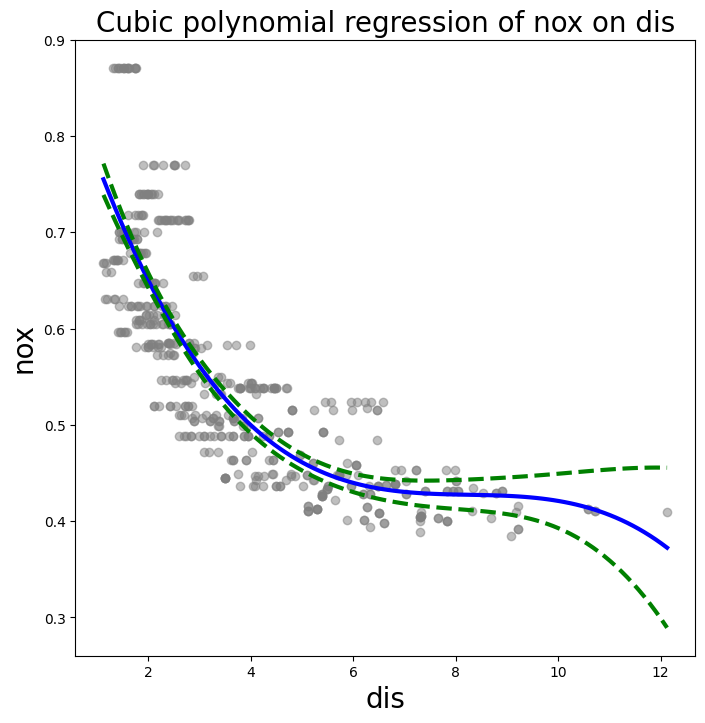

In [107]:
##Define the grid of predictor values
dis_grid = np.linspace(dis.min(), dis.max(), 100)
dis_df=pd.DataFrame({'dis':dis_grid})
dis2_df=pd.DataFrame({'dis':dis})
#Plot the results
Xnew2=model3.transform(dis_df)
preds = res.get_prediction(Xnew2)
bands = preds.conf_int(alpha=0.05)
fig, ax = subplots(figsize=(8,8))
ax.scatter(dis,nox,facecolor='gray',alpha=0.5)
for val, ls in zip([preds.predicted_mean,bands[:,0],bands[:,1]],['b','g--','g--']):
        ax.plot(dis_df.values, val, ls, linewidth=3)
ax.set_title('Cubic polynomial regression of nox on dis', fontsize=20)
ax.set_xlabel('dis', fontsize=20)
ax.set_ylabel('nox', fontsize=20);

#### Brief explanation of the above graph:
- The blues lines indicates pollution decreases. However, not in a straight line rather in a curve. The decrease is rapid at the initial stage, then it later slows down.
- The blue line shows the relation between dis and nox.
- 95% confidence interval   of uncertainty in this prediction.  
- The orange lines are actual data points. It shows the natural variation.
In real sense, air pollutio is the highest near center  and drop.

In [81]:
preds = preds.predicted_mean.reshape(-1,1)
preds.shape

(100, 1)

##### (b) Plot the polynomial fits for a range of different polynomial degrees (say, from 1 to 10), and report the associated residual sum of squares.


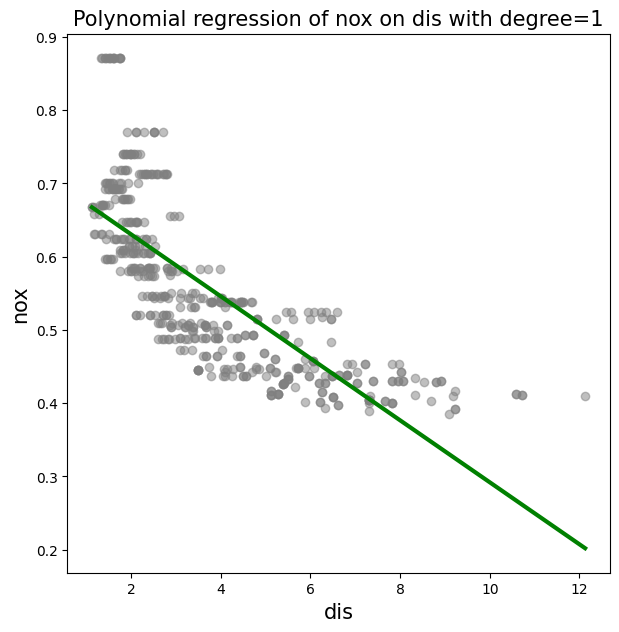

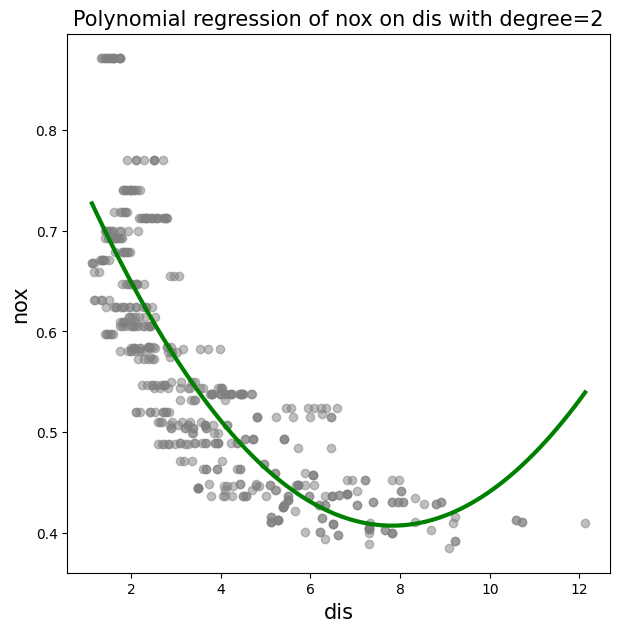

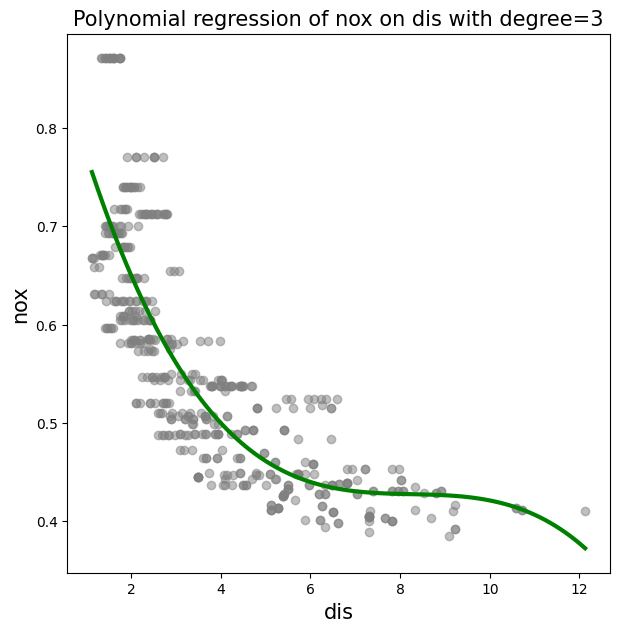

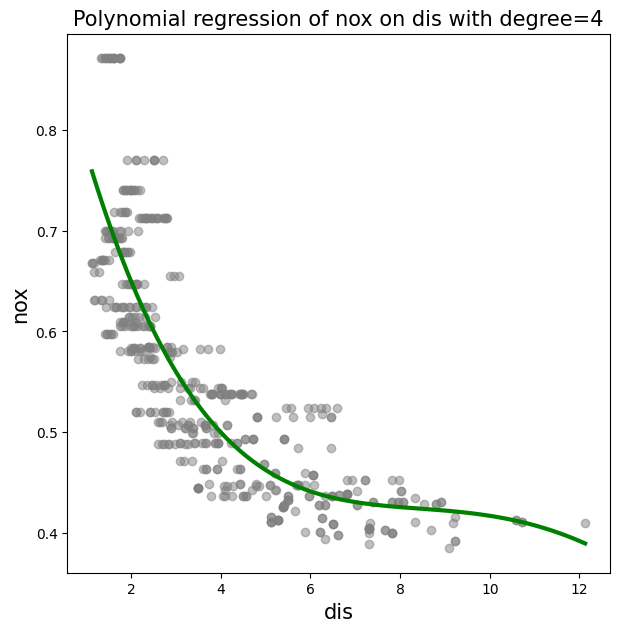

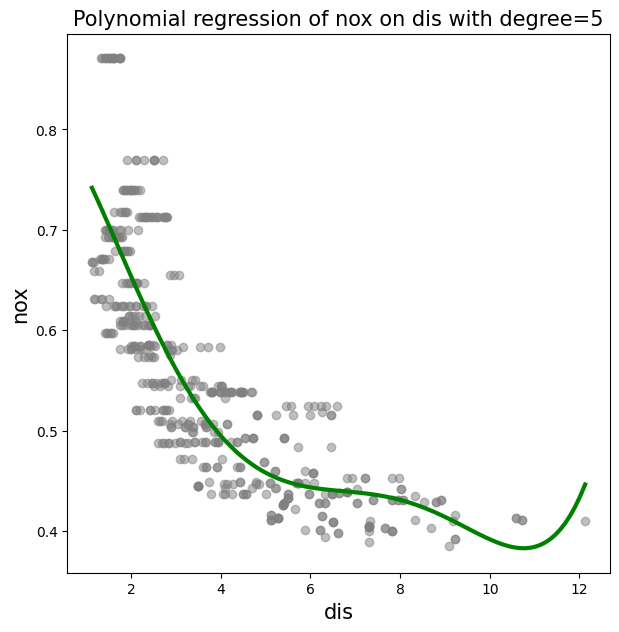

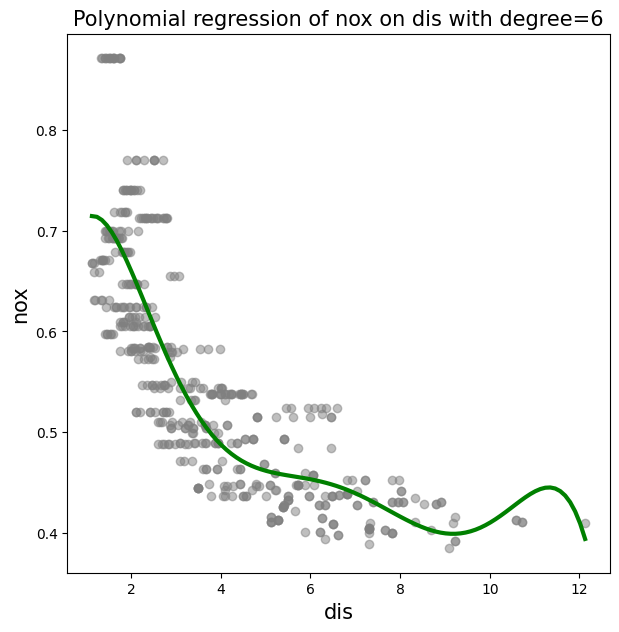

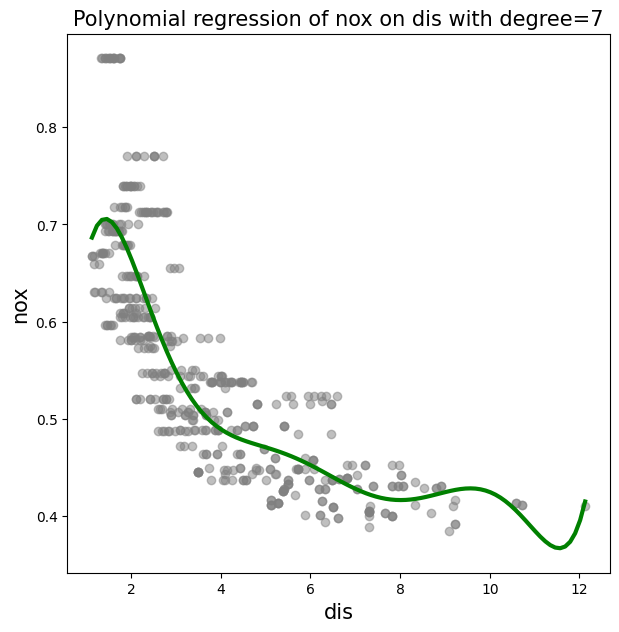

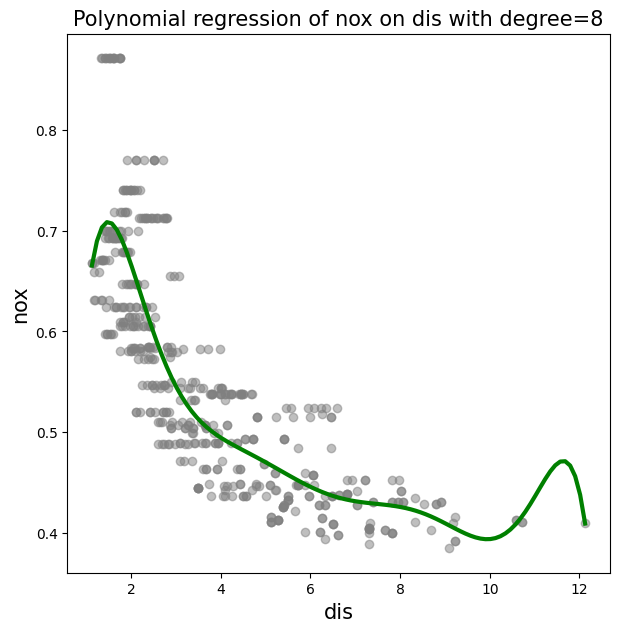

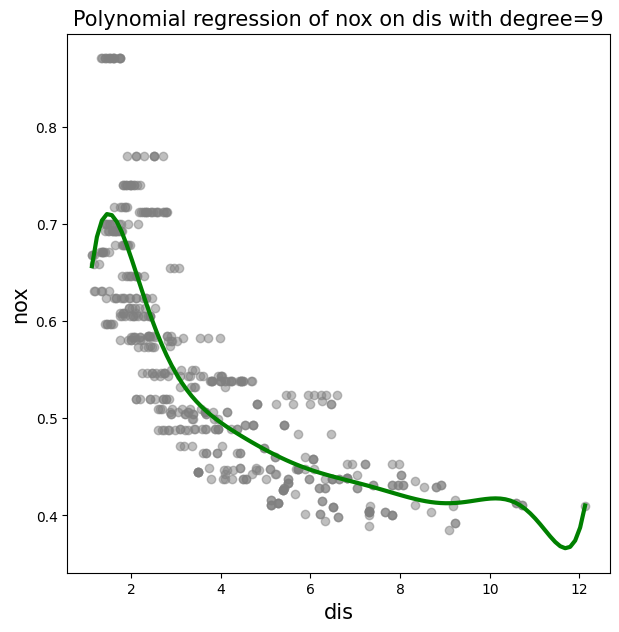

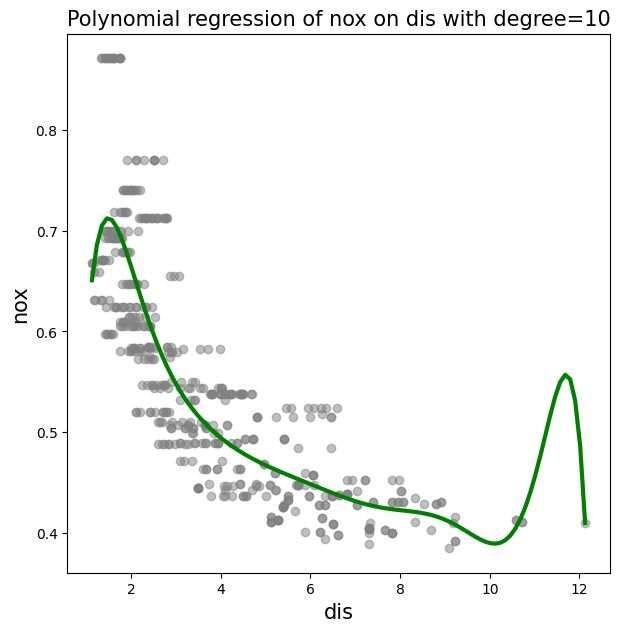

In [108]:
RSS={}
for d in range(1,11):
    model=MS([poly('dis', degree=d)]).fit(Boston)
    X=model.transform(Boston)
    res=sm.OLS(nox, X).fit()
    Xnew=model.transform(dis_df)
    Xnew2=model.transform(dis2_df)
    preds = res.get_prediction(Xnew)
    yhat=res.get_prediction(Xnew2)
    yhat=yhat.predicted_mean
    RSS[d]=np.sum((nox - yhat)**2)
    fig, ax = subplots(figsize=(7,7))
    ax.scatter(dis,nox,facecolor='gray',alpha=0.5)
    ax.plot(dis_df.values,preds.predicted_mean , 'green', linewidth=3)
    ax.set_title('Polynomial regression of nox on dis with degree='+ str(d), fontsize=15)
    ax.set_xlabel('dis', fontsize=15)
    ax.set_ylabel('nox', fontsize=15);

In [83]:
pd.DataFrame(RSS,index = ['RSS']).T

,RSS
1,2.768563
2,2.035262
3,1.934107
4,1.932981
5,1.915290
6,1.878257
7,1.849484
8,1.835630
9,1.833331
10,1.832171


Insight Derived:
- From 1 to 2 parameters, the RSS drops by .73 i.e 26% improemt. And also from 2-3 parameters, the RSS drop by .10 i.e 5% improvements.

- Therefore, adding more parameters consistently improves fit, but the benefits diminish rapidly. 
- The sweet spot appears around 5-6 parameters where we get good fit without unnecessary complexity. 

-Summarily, as expected , the training RSE decreases with the polynomial degrees. 


#### (c) Perform cross-validation or another approach to select the optimal degree for the polynomial, and explain your results.


In [ ]:
# Using cross validation(cv=5) to find the best polynomial degree. 
cv_error = np.zeros(11)
H = np.array(dis)
M = sklearn_sm(sm.OLS)

cv = KFold(n_splits=5,shuffle=True,random_state=0)
for i, d in enumerate(range(1,12)):
    Xcross = np.power.outer(H, np.arange(d+1))
    Mat_CV = cross_validate(M,Xcross,nox,cv=cv)
    cv_error[i] = np.mean(Mat_CV['test_score'])
cv_error

array([0.00550455, 0.00404589, 0.00384482, 0.00385288, 0.00405327,
       0.00490166, 0.00711742, 0.0065405 , 0.02188365, 0.00468493,
       0.0525854 ])

The best/optimal polynomial regression is for 3 degrees

##### (d) Use the bs() function to fit a regression spline to predict nox using dis. Report the output for the fit using four degrees of freedom. How did you choose the knots? Plot the resulting fit.


In [94]:
bs_dis = MS([bs('dis', df=4)]).fit(Boston)
M_bs = sm.OLS(nox, bs_dis.transform(Boston)).fit()
summarize(M_bs)

,coef,std err,t,P>|t|
intercept,0.7345,0.015,50.306,0.000
"bs(dis, df=4)[0]",-0.0581,0.022,-2.658,0.008
"bs(dis, df=4)[1]",-0.4636,0.024,-19.596,0.000
"bs(dis, df=4)[2]",-0.1998,0.043,-4.634,0.000
"bs(dis, df=4)[3]",-0.3888,0.046,-8.544,0.000


##### Detailed interpretation
From the above result, 
-  Degrees of freedom: 4 basis functions were used.
with the df = 4, it creates 2 interior knots placed at the 33.3% and 66.7%  qunatities of the data.
- Knot selection: The bs() function automatically placed knots at the quantiles of the dis variable.
- The fit quality: all splines terms are statistically significant, showing good cqpture of the non- linear relatioinship
- 

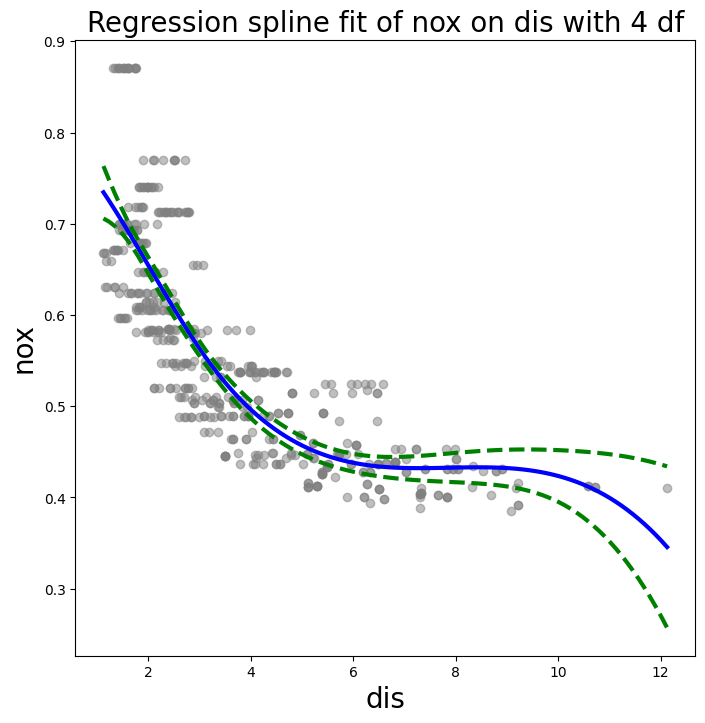

In [97]:
X = bs_dis.transform(Boston)
Xnew = bs_dis.transform(dis_df)
M = sm.OLS(nox, X).fit()
preds = M.get_prediction(Xnew)
bands = preds.conf_int(alpha=0.05)
fig, ax = subplots(figsize=(8,8))
ax.scatter(dis,nox,facecolor='gray',alpha=0.5)
for val, ls in zip([preds.predicted_mean,bands[:,0],bands[:,1]],['b','g--','g--']):
        ax.plot(dis_df.values, val, ls, linewidth=3)
ax.set_title('Regression spline fit of nox on dis with 4 df', fontsize=20)
ax.set_xlabel('dis', fontsize=20)
ax.set_ylabel('nox', fontsize=20);

#### (e) Now fit a regression spline for a range of degrees of freedom, and plot the resulting fits and report the resulting RSS. Describe the results obtained.


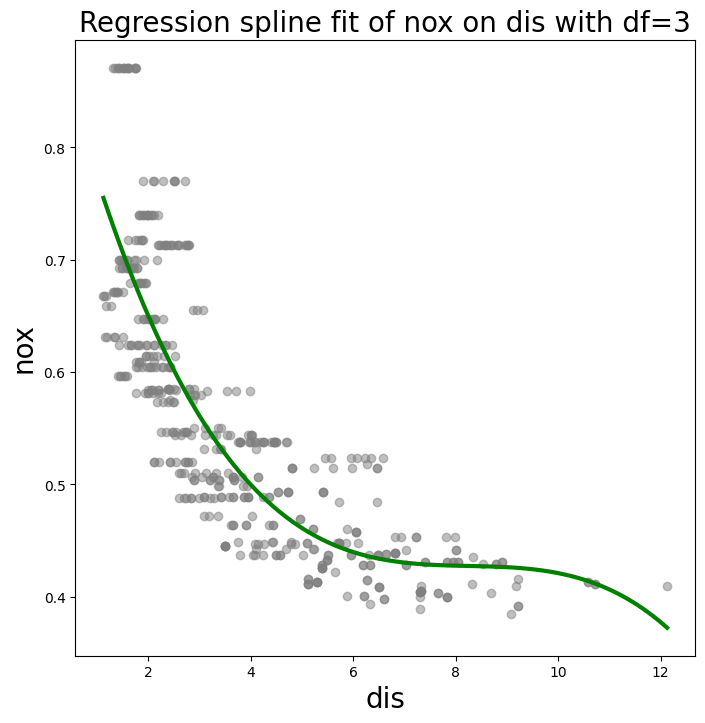

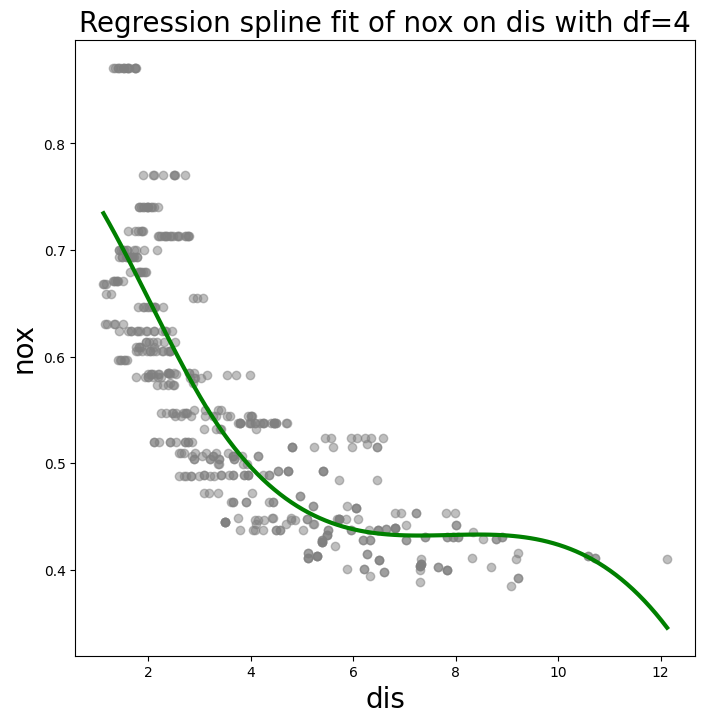

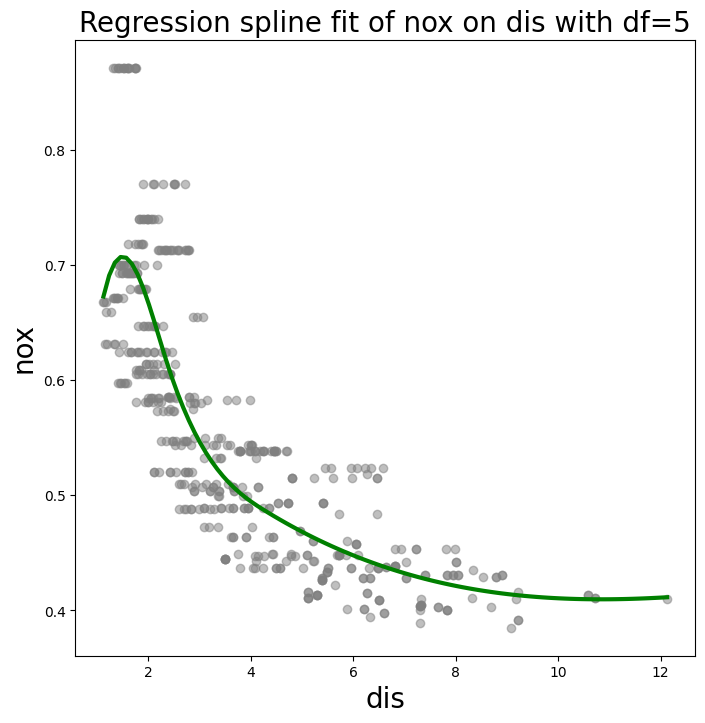

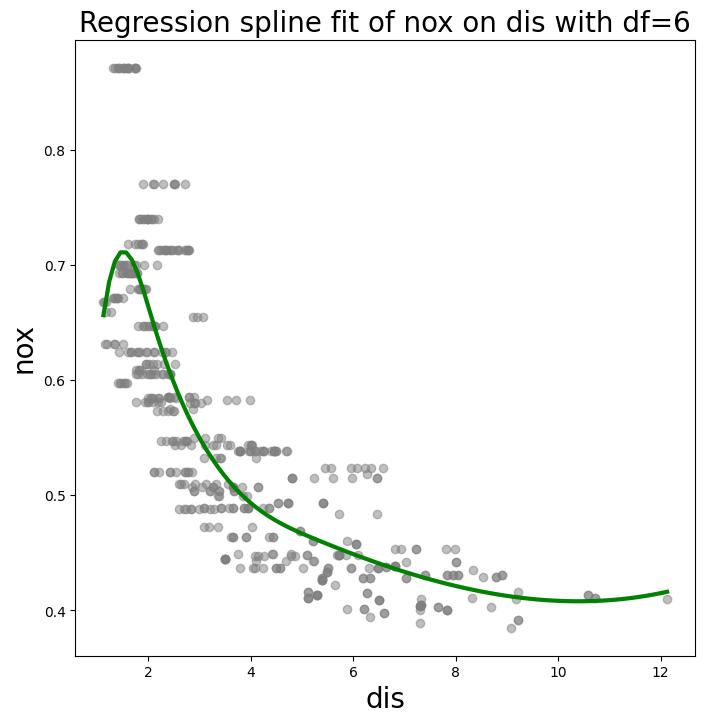

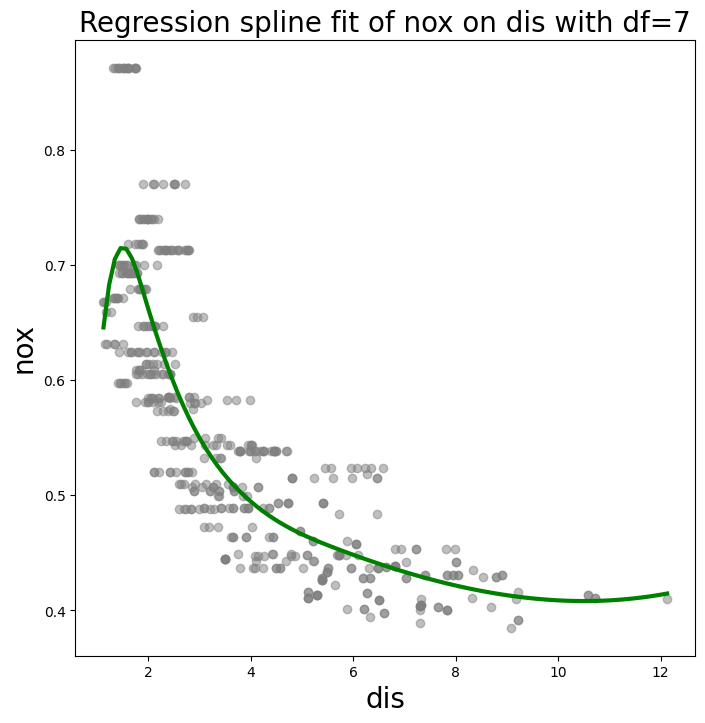

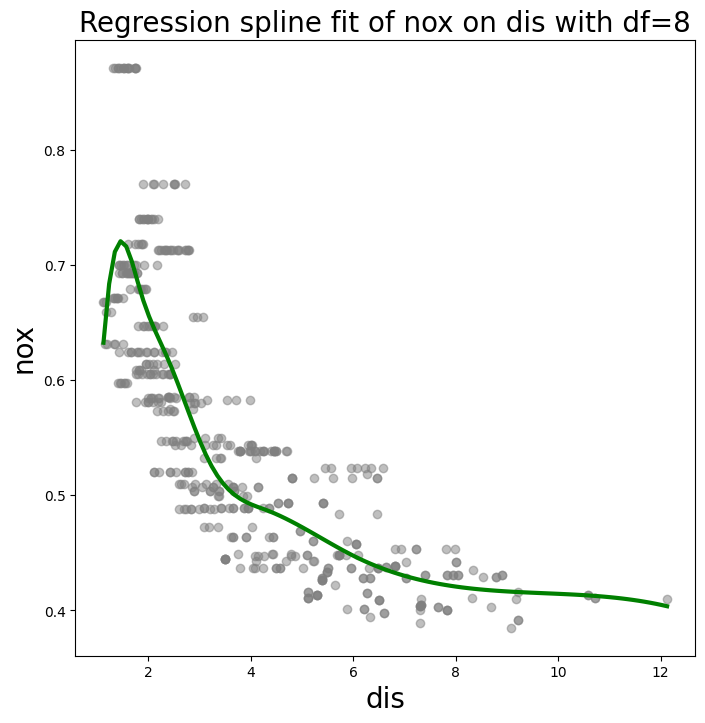

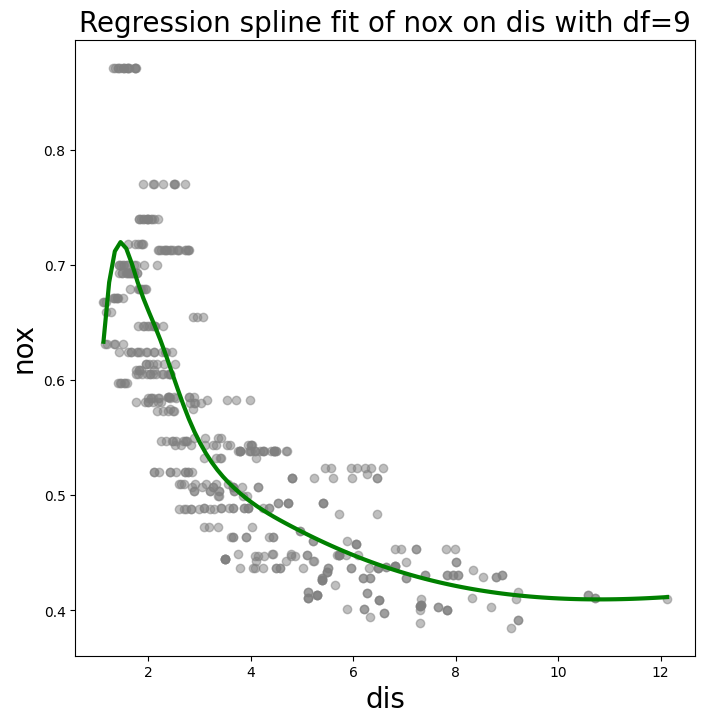

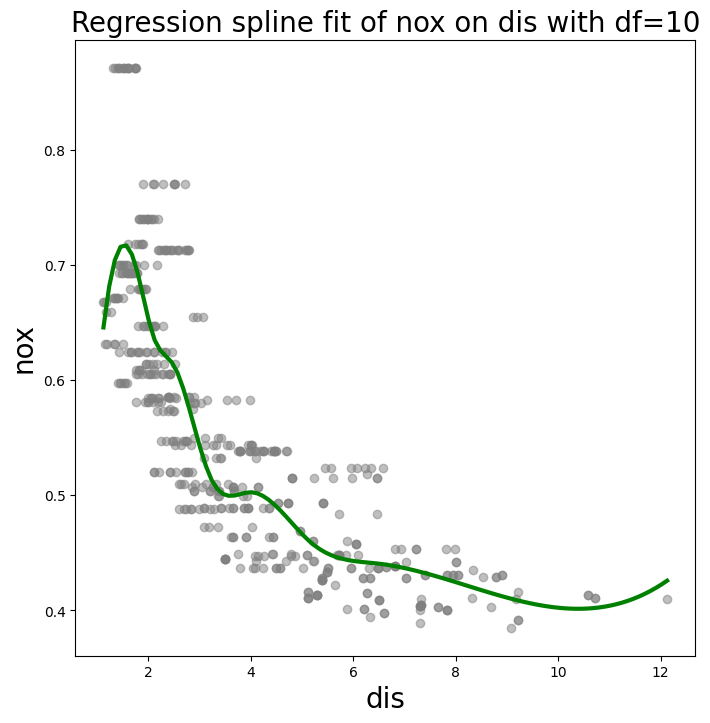

In [109]:
RSS={}
for d in range(3,11):
    bs_dis = MS([bs('dis', df=d)]).fit(Boston)
    M_bs = sm.OLS(nox, bs_dis.transform(Boston)).fit()
    Xnew = bs_dis.transform(dis_df)
    Xnew2=bs_dis.transform(dis2_df)
    preds = M_bs.get_prediction(Xnew)
    yhat=M_bs.get_prediction(Xnew2)
    yhat=yhat.predicted_mean
    RSS[d]=np.sum((nox - yhat)**2)
    bands = preds.conf_int(alpha=0.05)
    fig, ax = subplots(figsize=(8,8))
    ax.scatter(dis,nox,facecolor='gray',alpha=0.5)
    ax.plot(dis_df.values, preds.predicted_mean, 'green', linewidth=3)
    ax.set_title('Regression spline fit of nox on dis with df='+str(d), fontsize=20)
    ax.set_xlabel('dis', fontsize=20)
    ax.set_ylabel('nox', fontsize=20);

#### The description above results:
- There is a lower df from degree of freedom from 3-5, That means it has smoother, less flexible curves that capture the general trend.
- on the degree of freedom of  3-4 captures the decreasing trend.
- on the degree of freedom 5-7 captures some curvature relationship
- while from the degree of freedom from 8-10 are the higher ones, which is more wiggly, flexible curves that follow local patterns in the data.
- on the degree of freedom from 8-10 clearly shows overfitting with sever wiggles, most especially on the sparse data regions.

-However on the RSS:
it shows consistent decrease as degree of freedom increases. This is a bias-varaince tradeoff.
inconclusion: The decreasing RSS shows that adding flexibility improves training fit, but the best or optimal degree of freedom prediction is determined by using cross-validaion to avoid overfitting.

In [110]:
pd.DataFrame(RSS,index = ['RSS']).T

,RSS
3,1.934107
4,1.922775
5,1.840173
6,1.833966
7,1.829884
8,1.816995
9,1.825653
10,1.792535


The training RSS decreases with degrees of freedom. it cannot be decided that  which one is the best regression

#### (f) Perform cross-validation or another approach in order to select the best degrees of freedom for a regression spline on this data. Describe your results.


In [ ]:
#Take a cross validation to find the best regression spline model. cv=10
cv_error = np.zeros(9)
M = sklearn_sm(sm.OLS)
cv = KFold(n_splits=10,shuffle=True,random_state=1)
for d in range(3,12):
    bs_dis = MS([bs('dis', df=d)]).fit(Boston)
    Xcross = bs_dis.transform(Boston)
    Mat_CV = cross_validate(M,Xcross,nox,cv=cv)
    cv_error[d-3] = np.mean(Mat_CV['test_score'])
cv_error

array([0.00387002, 0.00388453, 0.0037093 , 0.0037177 , 0.00372454,
       0.00371579, 0.00375893, 0.00371381, 0.00373558])

The optimal model is obtained when the degrees of freedom  is 5 but the results looks unstable. 

### <font color = 'red'> QUESTION 10 IN CHAPTER  7

#### This question relates to the College data set.

##### (a) Split the data into a training set and a test set. Using out-of-state tuition as the response and the other variables as the predictors, perform forward stepwise selection on the training set in order to identify a satisfactory model that uses just a subset of the predictors.

In [112]:
College=load_data('College')

In [113]:

College_train, College_valid = train_test_split(College, test_size=0.5, random_state=0)

In [115]:
College['Private']=College['Private'].astype('category')
College_train['Private']=College_train['Private'].astype('category')
College_valid['Private']=College_valid['Private'].astype('category')
y = College_train['Outstate']
Vars_train = College_train.columns.drop(['Outstate'])
design = MS(Vars_train).fit(College_train)
X_train = design.transform(College_train)
College_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 388 entries, 54 to 684
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Private      388 non-null    category
 1   Apps         388 non-null    int64   
 2   Accept       388 non-null    int64   
 3   Enroll       388 non-null    int64   
 4   Top10perc    388 non-null    int64   
 5   Top25perc    388 non-null    int64   
 6   F.Undergrad  388 non-null    int64   
 7   P.Undergrad  388 non-null    int64   
 8   Outstate     388 non-null    int64   
 9   Room.Board   388 non-null    int64   
 10  Books        388 non-null    int64   
 11  Personal     388 non-null    int64   
 12  PhD          388 non-null    int64   
 13  Terminal     388 non-null    int64   
 14  S.F.Ratio    388 non-null    float64 
 15  perc.alumni  388 non-null    int64   
 16  Expend       388 non-null    int64   
 17  Grad.Rate    388 non-null    int64   
dtypes: category(1), float64(1), int64(

In [116]:
# Define the scoring system based on Cp coefficient
def nCp(sigma2, estimator, X, Y):
    "Negative Cp statistic"
    n, p = X.shape
    Yhat = estimator.predict(X)
    RSS = np.sum((Y - Yhat)**2)
    return -(RSS + 2 * p * sigma2) / n 
design_sigma = MS(College.columns.drop('Outstate')).fit(College)
Y_sigma = np.array(College['Outstate'])
X_sigma = design_sigma.transform(College)
sigma2 = OLS(Y_sigma,X_sigma).fit().scale
neg_Cp = partial(nCp, sigma2)

In [117]:
strategy=Stepwise.first_peak(design,direction='forward',max_terms=len(design.terms))
Outstate_MSE = sklearn_selected(OLS,strategy,scoring=neg_Cp)
Outstate_MSE.fit(College_train, y)
Outstate_MSE.selected_state_

('Accept',
 'Expend',
 'F.Undergrad',
 'Grad.Rate',
 'Personal',
 'Private',
 'Room.Board',
 'Terminal',
 'Top10perc',
 'perc.alumni')

### <font color = 'red'> Interpretation

The optimization of Cp coefficient shows that the best model obtained by forward stepwise selection relies on 10 predictors.

#### (b) Fit a GAM on the training data, using out-of-state tuition as the response and the features selected in the previous step as the predictors. Plot the results, and explain your findings.

In [127]:
gam = LinearGAM(s_gam(0)+ s_gam(1)+s_gam(2)+s_gam(3)+s_gam(4)+ f_gam(5, lam=0) 
                +s_gam(6)+s_gam(7)+s_gam(8)+s_gam(9))
Xgam = np.column_stack([College_train['Accept'],College_train['Expend'],College_train['F.Undergrad'],College_train['Grad.Rate'],
                        College_train['Personal'], College_train['Private'].cat.codes,College_train['Room.Board'],
                        College_train['Terminal'],College_train['Top10perc'],College_train['perc.alumni']])
gam = gam.fit(Xgam, y)

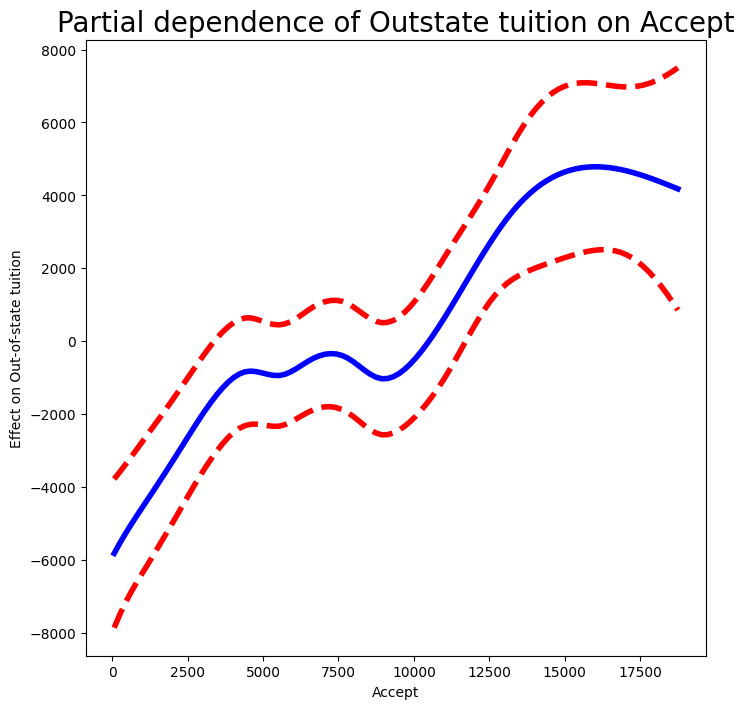

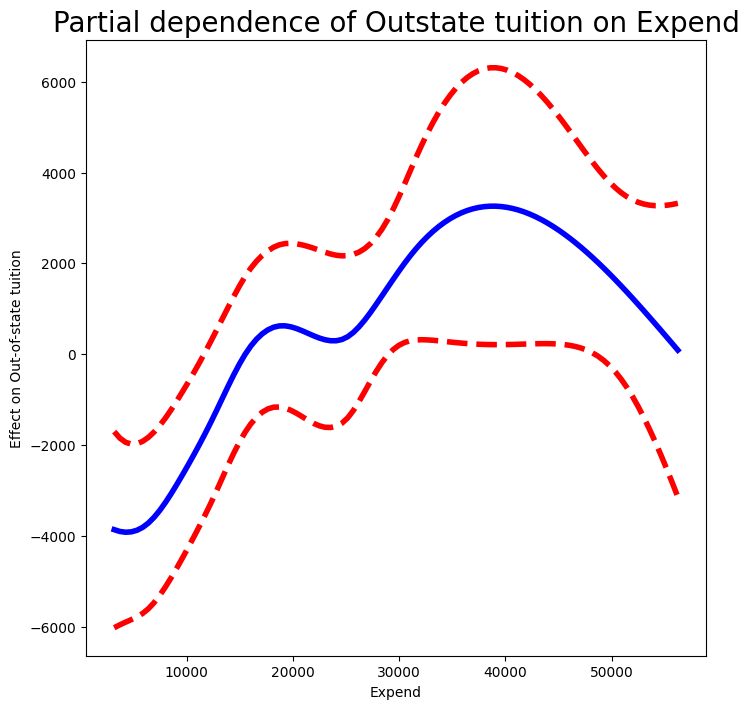

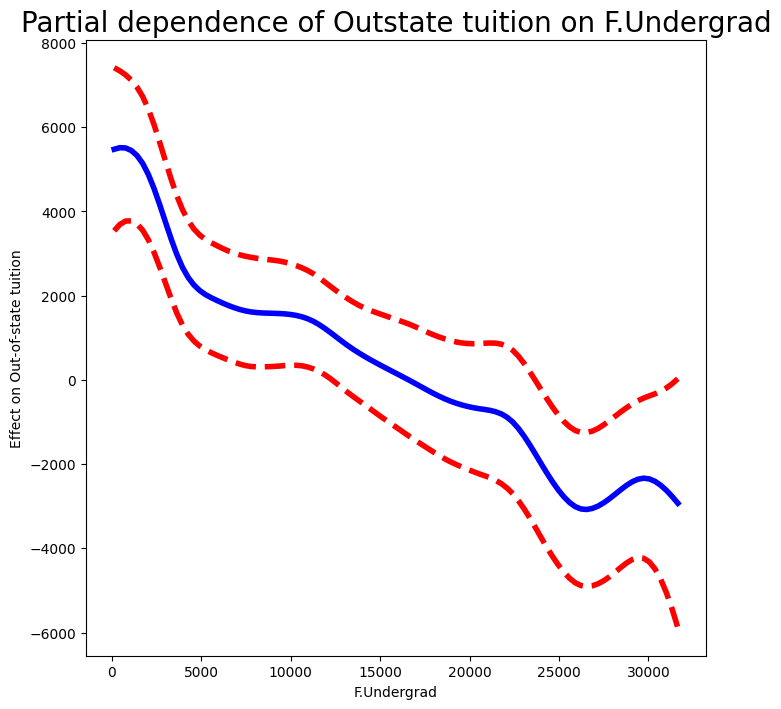

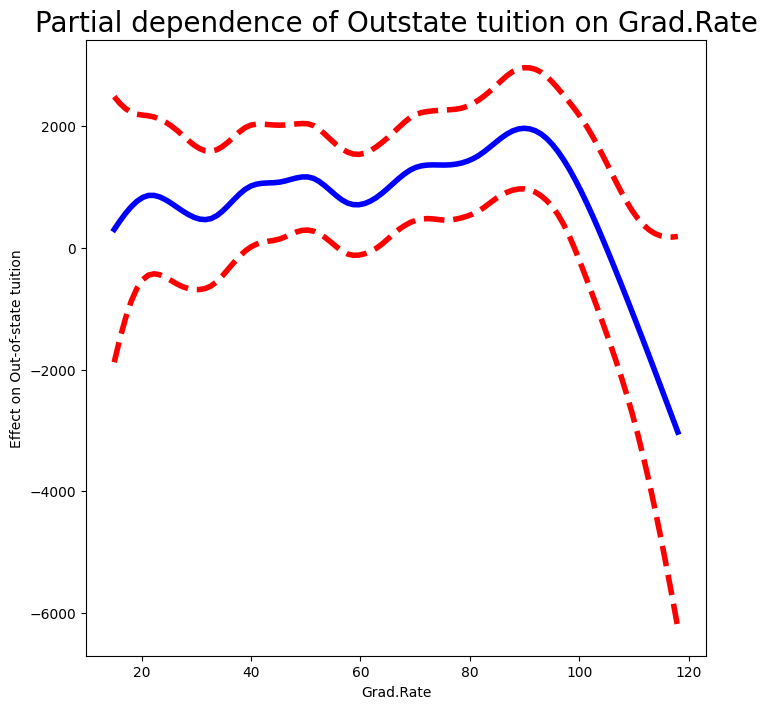

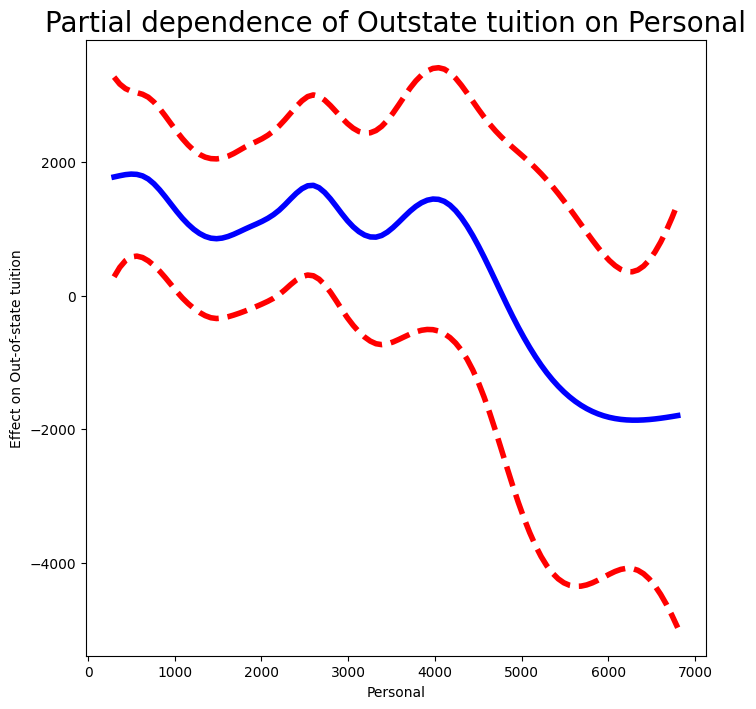

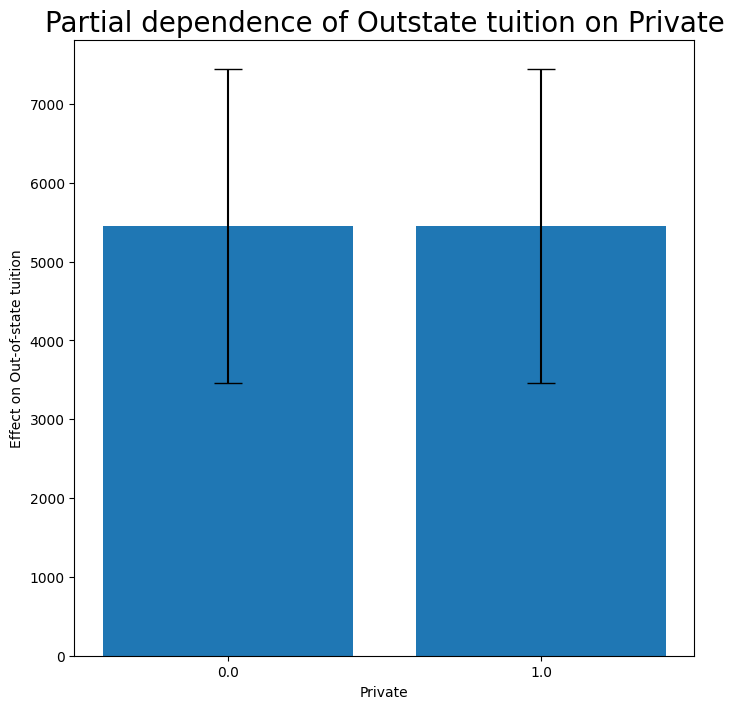

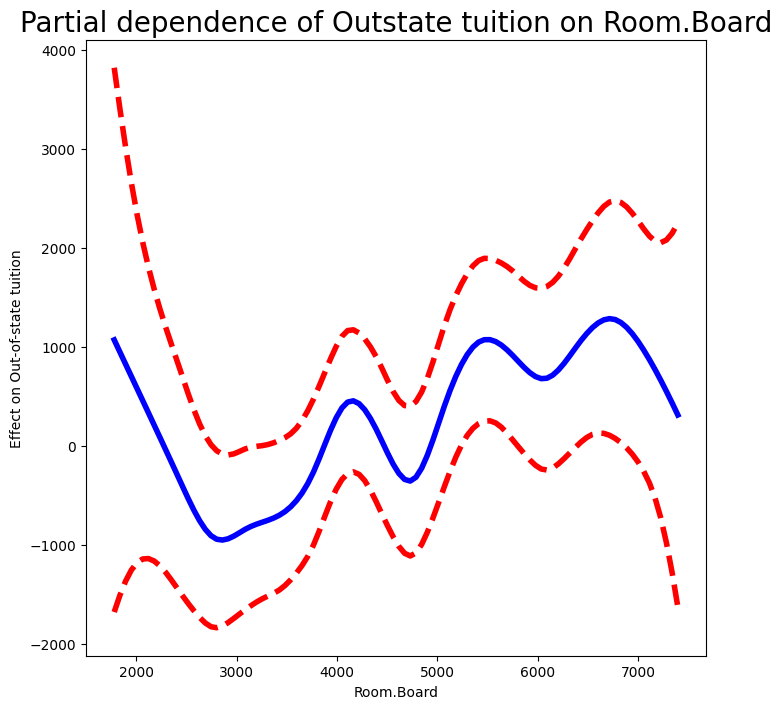

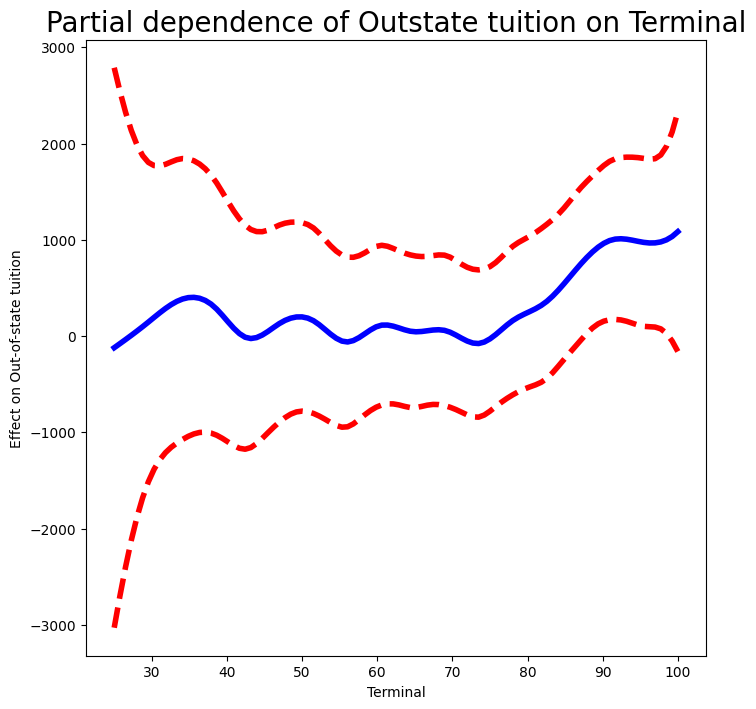

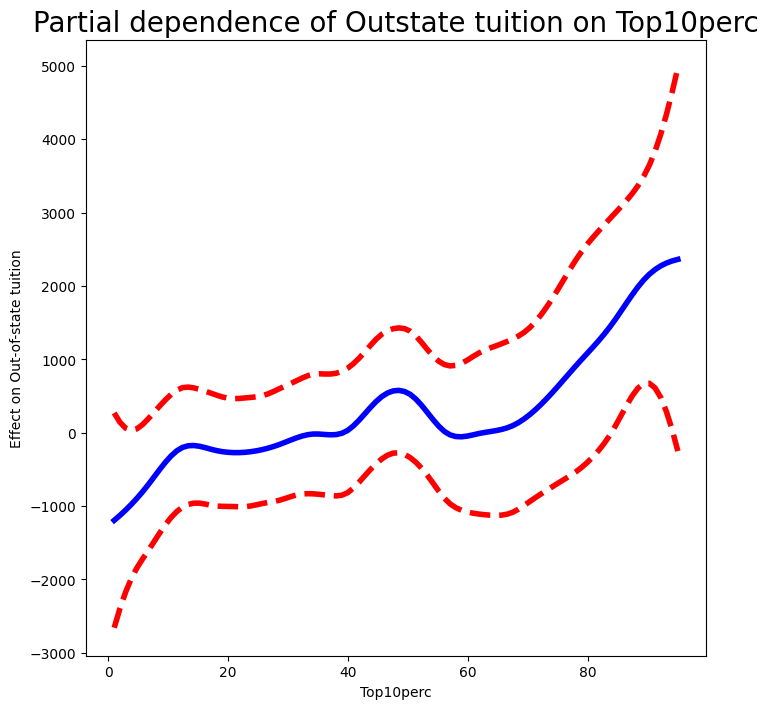

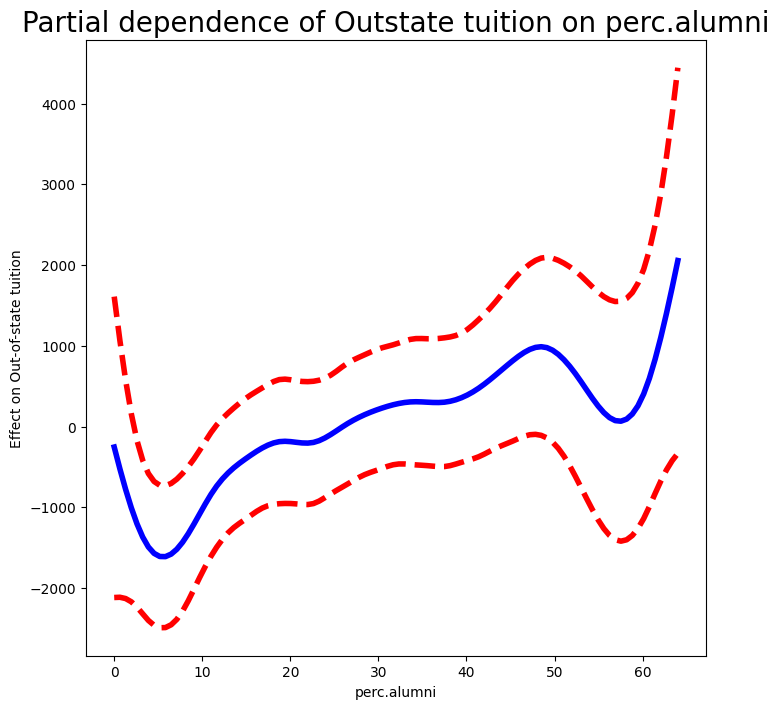

In [129]:
for d in Outstate_MSE.selected_state_:
    i=Outstate_MSE.selected_state_.index(d)
    fig, ax = subplots(figsize=(8, 8))
    ax = plot_gam(gam, i)
    ax.set_xlabel(d)
    ax.set_ylabel('Effect on Out-of-state tuition')
    ax.set_title('Partial dependence of Outstate tuition on '+d,fontsize=20);

 
 ### <font color = 'red'> Explanation

From the above plot, i discovered that some of the graphs represented display wiggly splines for instance the Outstate tuition on Terminal, which puts the gam model considered before into question. In order to select the best GAM model, one should consider the aformentionned cases and alternate between linear spline choices. The comparison of obtained models can be done also using ANOVA

one can choose to experiment with the following features due the roughness of their splines shown on the previous graphs on: 'perc.alumni', 'Room.Board' and 'Grad.Rate'.

In [120]:
gam2 = LinearGAM(s_gam(0)+ s_gam(1)+s_gam(2)+l_gam(3)+s_gam(4)+ f_gam(5, lam=0) 
                +l_gam(6)+s_gam(7)+s_gam(8)+l_gam(9))
gam2 = gam2.fit(Xgam, y)
anova_gam(gam2,gam)

,deviance,df,deviance_diff,df_diff,F,pvalue
0,1.107500e+09,331.378505,NaN,NaN,NaN,NaN
1,9.835192e+08,304.809671,1.239812e+08,26.568834,1.446203,0.104873


Based on the above table, it shows that 'gam' model is no better than the second. 
Hence gam2 will be adopted for the rest of the question.

##### (c) Evaluate the model obtained on the test set, and explain the results obtained.

In [ ]:
y_test=College_valid['Outstate']
X_test = np.column_stack([College_valid['Accept'],College_valid['Expend'],
                          College_valid['F.Undergrad'],College_valid['Grad.Rate'],
                        College_valid['Personal'], 
                          College_valid['Private'].cat.codes,College_valid['Room.Board'],
                        College_valid['Terminal'],College_valid['Top10perc'],
                          College_valid['perc.alumni']])

In [124]:
gam.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     83.1903
Link Function:                     IdentityLink Log Likelihood:                                 -6171.4888
Number of Samples:                          388 AIC:                                            12511.3582
                                                AICc:                                           12558.7292
                                                GCV:                                          5175682.4843
                                                Scale:                                        3226666.7927
                                                Pseudo R-Squared:                                   0.8459
Feature Function                  Lam

/tmp/ipykernel_9359/3358381670.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


In [125]:
gam2.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     56.6215
Link Function:                     IdentityLink Log Likelihood:                                  -6185.127
Number of Samples:                          388 AIC:                                            12485.4969
                                                AICc:                                           12506.0074
                                                GCV:                                          4508356.3536
                                                Scale:                                        3342101.0886
                                                Pseudo R-Squared:                                   0.8265
Feature Function                  Lam

/tmp/ipykernel_9359/263715579.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam2.summary()


 
 ### <font color = 'red'> Explanation

By using the stepwise forward selection, it became  a bad idea. The number of observations seem insufficient to bring stable results and splitting the already small dataset made things worse (Steyerberg et al. show that there must be at least 50 observations per feature to have acceptable results using stepwise selection. 

See : Prognostic modeling with logistic regression analysis: in search of a sensible strategy in small data sets. ). p-values don't reflect the correct values and hence they are not reliable. In a more realistic case it is better to avoid stepwise selection and opt for other approaches for feature selection like ridge regression.

##### (d) For which variables, if any, is there evidence of a non-linear relationship with the response?


From the above plot, 
looking intently, Yes, there is a non-linear relationship with the response on the following:
- partail dependence outstate tuition on Terminal, Room.Board and Grad.Rate because they have a slightly U-shape, S- shape, exponential, curvature or n shape.


 
 ### <font color = 'red'> QUESTION 8 IN CHAPTER 8

In [ ]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
from statsmodels.datasets import get_rdataset
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from ISLP.models import (ModelSpec as MS,summarize)
from sklearn.tree import (DecisionTreeClassifier as DTC,DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)
from sklearn.metrics import (accuracy_score,log_loss)
from sklearn.ensemble import (RandomForestRegressor as RF,GradientBoostingRegressor as GBR,
                             GradientBoostingClassifier as GBC,
                             BaggingClassifier as BC)
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression 
import statsmodels.api as sm
from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import (DecisionTreeClassifier as DTC,
                          DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)
from sklearn.metrics import (accuracy_score,
                             log_loss)
from sklearn.ensemble import \
     (RandomForestRegressor as RF,
      GradientBoostingRegressor as GBR)
from ISLP.bart import BART

##### 8. In the lab, a classification tree was applied to the Carseats data set after converting Sales into a qualitative response variable. Now we will seek to predict Sales using regression trees and related approaches, treating the response as a quantitative variable.

In [132]:
Carseats=load_data('Carseats')

In [133]:
model = MS(Carseats.columns.drop('Sales'), intercept=False)
D = model.fit_transform(Carseats)
feature_names = list(D.columns)
X = np.asarray(D)

##### (a) Split the data set into a training set and a test set. Please split it evenly in half.


In [134]:
(X_train, X_test, y_train, y_test) = skm.train_test_split(X,Carseats['Sales'],test_size=0.5,
                                                          random_state=30)

##### (b) Fit a regression tree to the training set. Plot the tree, and interpret the results. What test error rate do you obtain?

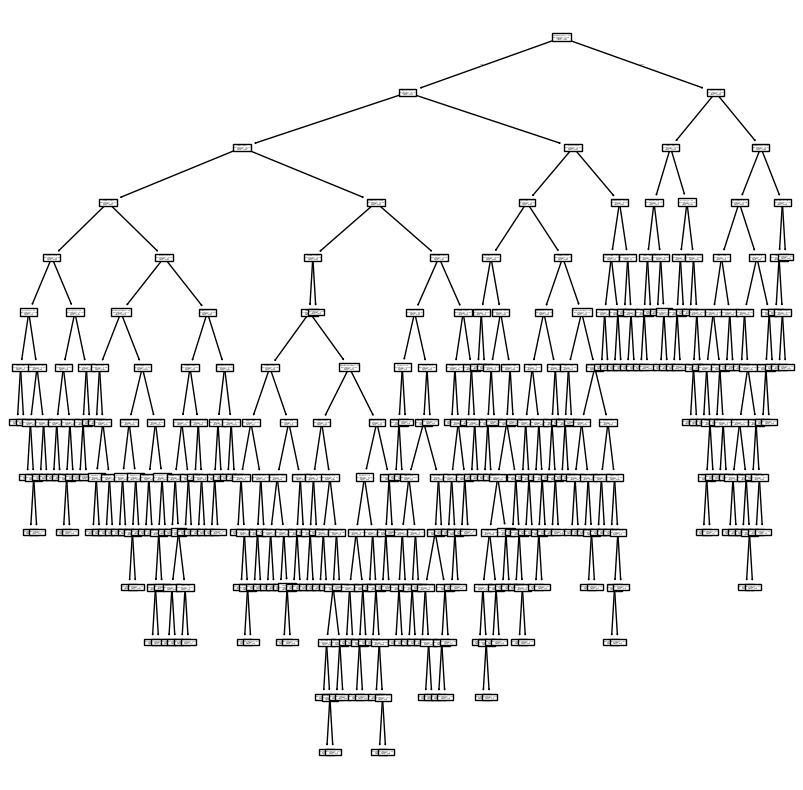

In [137]:
reg = DTR()
result=reg.fit(X_train, y_train)
ax = subplots(figsize=(10,10))[1]
plot_tree(reg,feature_names=feature_names,ax=ax);

In [138]:
ypred=result.predict(X_test)
MSE=np.mean((ypred-y_test)**2)
MSE

5.40221

In [139]:
result.get_depth()

13

 
 ### <font color = 'red'> Result and Explanation

I obtained test MSE as 5.40221.

This means that one  have to let the depth of the regression tree to be automatically obtained untill all the nodes are completely pure. The depth is 13.

##### (c) Use cross-validation in order to determine the optimal level of tree complexity. Does pruning the tree improve the test error rate?


In [140]:
ccp_path = reg.cost_complexity_pruning_path(X_train, y_train)
kfold = skm.KFold(5,shuffle=True,random_state=35)
grid = skm.GridSearchCV(reg,{'ccp_alpha': ccp_path.ccp_alphas},refit=True,cv=kfold,
                        scoring='neg_mean_squared_error')
G = grid.fit(X_train, y_train)

In [141]:
grid.best_estimator_.ccp_alpha

0.10074276955128325

The optimal tuning parameter obtained using cross-validation is 0.1007

In [142]:
best_model=grid.best_estimator_
pruning_MSE=np.mean((y_test-best_model.predict(X_test))**2)
pruning_MSE

5.051743739042897

 ### <font color = 'red'> Result and Explanation

Based on the above result, the cost complexity pruning produce to a test MSE of approximately around 5 which actually is better than the test MSE  obtained previously on the full regression tree.

##### (d) Use the bagging approach in order to analyze this data. What test error rate do you obtain? Use the importance() function to determine which variables are most important.

In [143]:
bag_seats = RF(max_features=X_train.shape[1], random_state=36)
bag_seats.fit(X_train, y_train)

RandomForestRegressor(max_features=11, random_state=36)

In [144]:
bag_seats = RF(max_features=X_train.shape[1], random_state=36)
bag_seats.fit(X_train, y_train)

RandomForestRegressor(max_features=11, random_state=36)

In [145]:
df=pd.DataFrame({'importance':bag_seats.feature_importances_},index=feature_names)
df.sort_values(by='importance', ascending=False)

,importance
Price,0.291835
ShelveLoc[Good],0.211079
Income,0.103316
Age,0.098761
CompPrice,0.095919
Advertising,0.056774
ShelveLoc[Medium],0.050990
Population,0.044953
Education,0.031706
Urban[Yes],0.009492


 ### <font color = 'red'> Result and Explanation

Considering the above results: the test MSE is just nearly halved after making use of the bagging. Futhermore, the top 3 most important predictors of Sales are listed below:
- Price, 
- ShelveLoc
- Income.

##### (e) Use random forests to analyze this data. What test error rate do you obtain? Use the importance() function to determine which variables are most important. Describe the effect of \(m\), the number of variables considered at each split, on the error rate obtained.

In [146]:
#Here am going to use number of features among p, p/2 and sqrt(p)
RF_MSE=np.zeros((1,3))
RF_seats1=RF(max_features=1.0,random_state=0).fit(X_train,y_train)
RF_seats2=RF(max_features=0.5,random_state=0).fit(X_train,y_train)
RF_seats3=RF(max_features='sqrt',random_state=0).fit(X_train,y_train)
ypred1=RF_seats1.predict(X_test)
ypred2=RF_seats2.predict(X_test)
ypred3=RF_seats3.predict(X_test)
RF_MSE[0,0]=np.mean((y_test - ypred1)**2)
RF_MSE[0,1]=np.mean((y_test - ypred2)**2)
RF_MSE[0,2]=np.mean((y_test - ypred3)**2)

In [147]:
RF_MSE

array([[2.57109663, 2.75792513, 3.04815656]])

 ### <font color = 'red'> Result and Explanation

Looking at the above result: the optimal test MSE  obaitned with a random forests is around 2.57 which is quiet practically the same for bagging.
Additionally, changing m has resulted in the change of the test MSE form 2.57 to 3.05.

In [148]:
df=pd.DataFrame({'importance':RF_seats1.feature_importances_},index=feature_names)
df.sort_values(by='importance', ascending=False)

,importance
Price,0.296556
ShelveLoc[Good],0.214089
Income,0.101554
CompPrice,0.100222
Age,0.089137
Advertising,0.056200
ShelveLoc[Medium],0.051287
Population,0.045874
Education,0.031734
Urban[Yes],0.008122


From the previous question, as obtained, the most important features in Sales prediction are: 
- Price
- ShelveLoc 
- Income

##### (f) Now analyze the data using BART, and report your results.

In [162]:
from ISLP.bart import BART

In [163]:
bart_boston = BART(random_state=0, burnin=5, ndraw=15)
bart_boston.fit(X_train, y_train)


BART(burnin=5, ndraw=15, random_state=0)

In [166]:
yhat_test = bart_boston.predict(X_test.astype(np.float32))
np.mean((y_test - yhat_test)**2)

1.3024315144273169

 ### <font color = 'red'> Report of the Result 

According to the above result, the test MSE obtained with BART is 1.3024, which is half of both random forests and bagging approaches used. Therefore, one can see that BART is truly competitive.


 ### <font color = 'red'> APPLIED EXERCISE 9 CHAPTER 12


In [193]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from ISLP import load_data


from sklearn.cluster import \
     (KMeans,
      AgglomerativeClustering)
from scipy.cluster.hierarchy import \
     (dendrogram,
      cut_tree)
from ISLP.cluster import compute_linkage


In [194]:
USArrests=get_rdataset('USArrests').data
scaler=StandardScaler(with_std=True,with_mean=True)
USArrestscaled=scaler.fit_transform(USArrests)

#### 9. Consider the USArrests data. We will now perform hierarchical clustering on the states.

#### (a) Using hierarchical clustering with complete linkage and Euclidean distance, cluster the states.


In [195]:
HClust = AgglomerativeClustering
hc_comp = HClust(distance_threshold=0,n_clusters=None,linkage='complete')
hc_comp.fit(USArrests)

AgglomerativeClustering(distance_threshold=0, linkage='complete',
                        n_clusters=None)

#### (b) Cut the dendrogram at a height that results in three distinct clusters. Which states belong to which clusters?


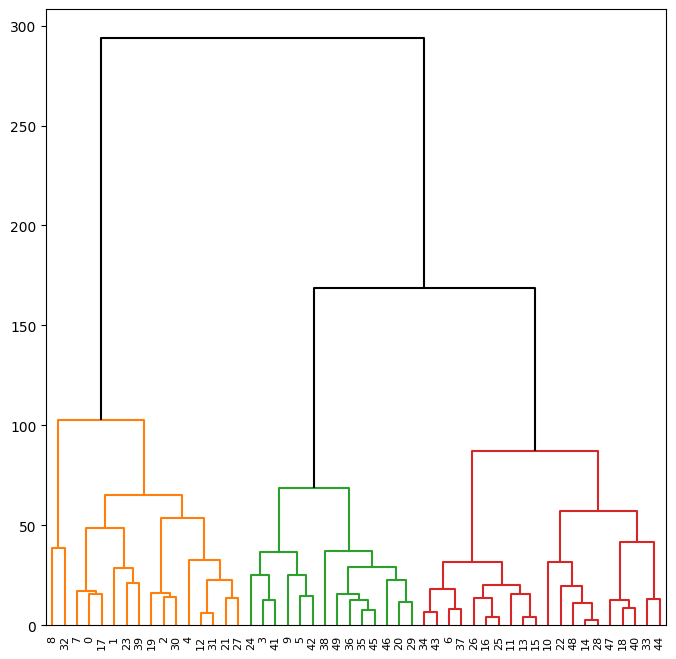

In [196]:
linkage_comp = compute_linkage(hc_comp)
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
dendrogram(linkage_comp,ax=ax,color_threshold=120, above_threshold_color='black');

In [197]:
USArrests.index

Index(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
       'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
       'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
       'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
       'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
       'New Hampshire', 'New Jersey', 'New Mexico', 'New York',
       'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon',
       'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota',
       'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington',
       'West Virginia', 'Wisconsin', 'Wyoming'],
      dtype='object', name='rownames')

In [198]:
df1=pd.DataFrame(cut_tree(linkage_comp, n_clusters=3),index=USArrests.index)
df1.index.name='State'
df1.rename(columns={0:'Cluster'},inplace=True)

In [199]:
df1

,Cluster
State,
Alabama,0
Alaska,0
Arizona,0
Arkansas,1
California,0
Colorado,1
Connecticut,2
Delaware,0
Florida,0


#### (c) Hierarchically cluster the states using complete linkage and Euclidean distance, after scaling the variables to have standard deviation one.


In [200]:
HClust = AgglomerativeClustering
hc_comp = HClust(distance_threshold=0,n_clusters=None,linkage='complete')
hc_comp.fit(USArrestscaled)

AgglomerativeClustering(distance_threshold=0, linkage='complete',
                        n_clusters=None)

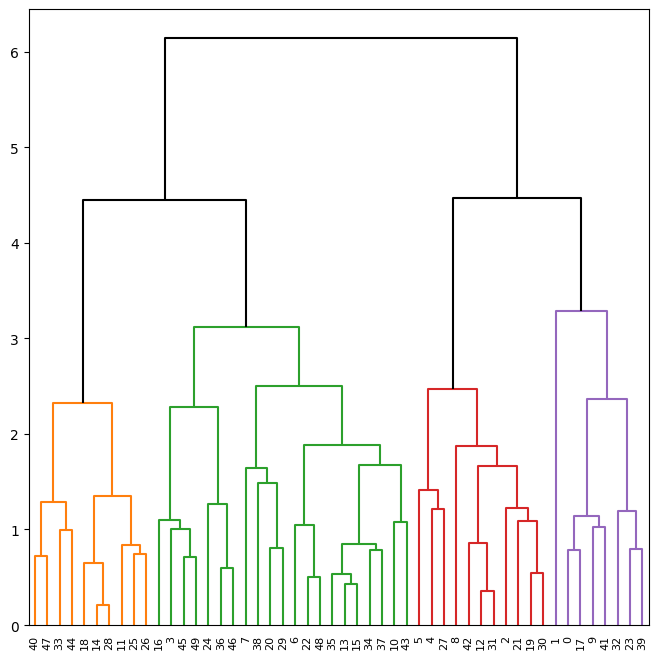

In [201]:
linkage_comp = compute_linkage(hc_comp)
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
dendrogram(linkage_comp,ax=ax,color_threshold=4, above_threshold_color='black');

In [202]:
df2=pd.DataFrame(cut_tree(linkage_comp, n_clusters=3),index=USArrests.index)
df2.index.name='State'
df2.rename(columns={0:'Cluster'},inplace=True)

In [203]:
df2

,Cluster
State,
Alabama,0
Alaska,0
Arizona,1
Arkansas,2
California,1
Colorado,1
Connecticut,2
Delaware,2
Florida,1


##### (d) What effect does scaling the variables have on the hierarchical clustering obtained? In your opinion, should the variables be scaled before the inter-observation dissimilarities are computed? Provide a justification for your answer.


In [204]:
df= df1.join(df2, lsuffix='_Unscaled', rsuffix='_Scaled')

In [205]:
df

,Cluster_Unscaled,Cluster_Scaled
State,,
Alabama,0,0
Alaska,0,0
Arizona,0,1
Arkansas,1,2
California,0,1
Colorado,1,1
Connecticut,2,2
Delaware,0,2
Florida,0,1


In [206]:
df['Cluster_Unscaled'][df['Cluster_Unscaled']==0].count()

16

In [207]:
df['Cluster_Scaled'][df['Cluster_Scaled']==0].count()

8

In [208]:
df['Cluster_Unscaled'][df['Cluster_Unscaled']==1].count()

14

In [209]:
df['Cluster_Scaled'][df['Cluster_Scaled']==1].count()

11


 ### <font color = 'red'> The answer to the above question is clearly explained below


Scaling variables tends to increase the observations in the third cluster.
The variables should be scaled before doing hierchical clustering in this case because feature units are different. For example, Murder is a rate per 100,000 while UrbanPop is a percentage of urban poulation.


 ### <font color = 'red'> APPLIED EXERCISE 10 CHAPTER 12


##### 10. In this problem, you will generate simulated data, and then perform PCA and \(K\)-means clustering on the data.


##### (a) Generate a simulated data set with 20 observations in each of three classes (i.e. 60 observations total), and 50 variables. Hint: There are a number of functions in Python that you can use to generate data. One example is the normal() method of the random() function in numpy; the uniform() method is another option. Be sure to add a mean shift to the observations in each class so that there are three distinct classes.

In [187]:
np.random.seed(1)
X = np.random.rand(60,50)
X[:20,:20] += 1
X[20:40,20:40] -= 1

In [ ]:
y=np.concatenate((np.repeat(0,20),np.repeat(1,20),np.repeat(2,20)))

##### (b) Perform PCA on the 60 observations and plot the first two principal component score vectors. Use a different color to indicate the observations in each of the three classes. If the three classes appear separated in this plot, then continue on to part (c). If not, then return to part (a) and modify the simulation so that there is greater separation between the three classes. Do not continue to part (c) until the three classes show at least some separation in the first two principal component score vectors.

In [189]:
pca=PCA()
pca_X=pca.fit_transform(X)

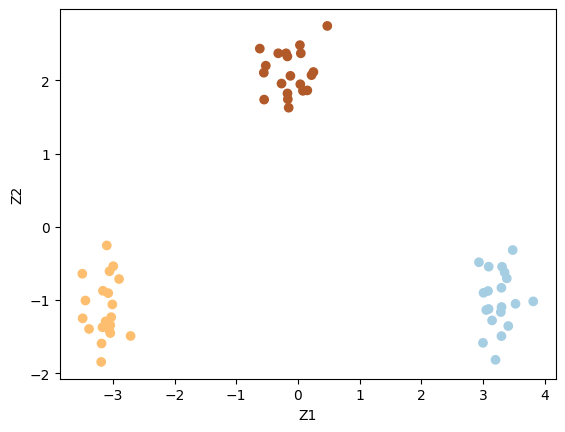

In [190]:
plt.scatter(pca_X[:,0], pca_X[:,1], c=y, cmap=mpl.cm.Paired)
plt.xlabel('Z1')
plt.ylabel('Z2');

##### (c) Perform K-means clustering of the observations with K = 3. How well do the clusters that you obtained in K-means clustering compare to the true class labels? Hint: You can use the pd.crosstab() function in Python to compare the true class labels to the class labels obtained by clustering. Be careful how you interpret the results: K-means clustering will arbitrarily number the clusters, so you cannot simply check whether the true class labels and clustering labels are the same.

In [191]:
kmeans_3C = KMeans(n_clusters=3,random_state=2,n_init=20).fit(X)
pd.crosstab(index=kmeans_3C.labels_,columns=y,rownames=['kmeans_3C'],colnames=['y'])

y,0,1,2
kmeans_3C,,,
0,0,20,0
1,20,0,0
2,0,0,20


As shown above, Since K-means clustering randomly assigns numbers to the clusters, one can conclude that it had correctly identified the 3 real clusters.

##### (d) Perform K-means clustering with K = 2. Describe your results.

In [192]:
kmeans_2C = KMeans(n_clusters=2,random_state=3,n_init=20).fit(X)
pd.crosstab(index=kmeans_2C.labels_,columns=y,rownames=['kmeans_2C'],colnames=['y'])

y,0,1,2
kmeans_2C,,,
0,20,0,0
1,0,20,20


According to this one: K-means identifies classes 1 and 2 as relation to the same cluster.

##### (e) Now perform K-means clustering with K = 4, and describe your results

In [211]:
kmeans_4C = KMeans(n_clusters=4,random_state=4,n_init=20).fit(X)
pd.crosstab(index=kmeans_4C.labels_,columns=y,rownames=['kmeans_4C'],colnames=['y'])

y,0,1,2
kmeans_4C,,,
0,0,20,0
1,10,0,0
2,0,0,20
3,10,0,0


From above,the K-means splits class 0 in two halves over two clusters.

##### (f) Now perform K-means clustering with K = 3 on the first two principal component score vectors, rather than on the raw data. That is, perform K-means clustering on the 60 × 2 matrix of which the first column is the first principal component score vector, and the second column is the second principal component score vector. Comment on the results.

In [212]:
kmeans_3C_pca = KMeans(n_clusters=3,random_state=5,n_init=20).fit(pca_X[:,:2])
pd.crosstab(index=kmeans_3C_pca.labels_,columns=y,rownames=['kmeans_3C_pca'],colnames=['y'])

y,0,1,2
kmeans_3C_pca,,,
0,20,0,0
1,0,0,20
2,0,20,0


It repeated, like with the raw data, K-means accurately identifies clusters.

##### (g) Using the StandardScaler() estimator, perform K-means clustering with K = 3 on the data after scaling each variable to have standard deviation one. How do these results compare to those obtained in (b)? Explain.

In [213]:
scaled_X=StandardScaler().fit_transform(X)
kmeans_3C_stds = KMeans(n_clusters=3,random_state=6,n_init=20).fit(scaled_X)
pd.crosstab(index=kmeans_3C_stds.labels_,columns=y,rownames=['kmeans_3C_stds'],colnames=['y'])

y,0,1,2
kmeans_3C_stds,,,
0,0,0,20
1,20,0,0
2,0,20,0


Repeatedly, The K-means accuratley identifies the clusters formed in (b) also.